In [122]:
import pandas as pd

df = pd.read_csv("data/Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Dataset Problem:
- Data chưa được chuẩn hoá

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [124]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [125]:
# chuẩn hoá tên các cột
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [126]:
df.duplicated().sum()

np.int64(0)

In [127]:
# Null report: count + tỷ lệ % + dtype
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "số_null": null_counts,
    "null_pct (%)": null_pct,
    "dtype": df.dtypes
})

print(f"Tổng số dòng: {len(df)}")
print(f"Số cột có null: {(null_counts > 0).sum()}\n")
missing_report

Tổng số dòng: 9994
Số cột có null: 0



,số_null,null_pct (%),dtype
row_id,0,0.0,int64
order_id,0,0.0,object
order_date,0,0.0,object
ship_date,0,0.0,object
ship_mode,0,0.0,object
customer_id,0,0.0,object
customer_name,0,0.0,object
segment,0,0.0,object
country,0,0.0,object
city,0,0.0,object


In [128]:
# Kiểm tra các empty string trong cột object
obj_cols = df.select_dtypes(include="object").columns

empty_str_counts = df[obj_cols].apply(lambda col: col.str.strip().eq("").sum())

pd.DataFrame({
    "empty_string_count": empty_str_counts,
    "empty_pct (%)": (empty_str_counts / len(df) * 100).round(2)
})


,empty_string_count,empty_pct (%)
order_id,0,0.0
order_date,0,0.0
ship_date,0,0.0
ship_mode,0,0.0
customer_id,0,0.0
customer_name,0,0.0
segment,0,0.0
country,0,0.0
city,0,0.0
state,0,0.0


In [129]:
# Check về mặt logic
issues = {}

# check xem ship_date có bị nhỏ hơn order_date không
issues["ship_date < order_date"] = df[df["ship_date"] < df["order_date"]]

# check xem sales có lớn hơn or < 0 không
issues["sales <= 0"] = df[df["sales"] <= 0]

# check xem quantity có > 1 không
issues["quantity < 1"] = df[df["quantity"] < 1]

# check xem Discount ngoài khoảng [0, 1]
issues["discount ngoài [0, 1]"] = df[(df["discount"] < 0) | (df["discount"] > 1)]

# check xem Profit outlier cực âm (dưới mean - 3σ)
profit_mean, profit_std = df["profit"].mean(), df["profit"].std()
issues[f"profit < mean − 3σ  ({profit_mean - 3*profit_std:.1f})"] = df[df["profit"] < profit_mean - 3 * profit_std]

# Tổng hợp
for label, bad_rows in issues.items():
    status = "⚠️  CÓ VẤN ĐỀ" if len(bad_rows) > 0 else "✓  OK"
    print(f"{status} | {label}: {len(bad_rows)} dòng")

⚠️  CÓ VẤN ĐỀ | ship_date < order_date: 1565 dòng
✓  OK | sales <= 0: 0 dòng
✓  OK | quantity < 1: 0 dòng
✓  OK | discount ngoài [0, 1]: 0 dòng
⚠️  CÓ VẤN ĐỀ | profit < mean − 3σ  (-674.1): 37 dòng


- Nhận xét, có 37 dòng profit âm lớn, check xem thử

In [130]:
# Xem thử các dòng đó trông như thế nào
extreme_loss = df[df["profit"] < profit_mean - 3 * profit_std]
extreme_loss[["order_id", "product_name", "category", "sales", "discount", "profit"]].sort_values("profit")


,order_id,product_name,category,sales,discount,profit
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,Technology,4499.985,0.7,-6599.9780
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,Technology,7999.980,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,Office Supplies,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,Technology,2549.985,0.7,-3399.9800
4991,US-2017-122714,Ibico EPK-21 Electric Binding System,Office Supplies,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Cubify CubeX 3D Printer Double Head Print,Technology,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4297.644,0.4,-1862.3124
1199,CA-2016-130946,GBC DocuBind P400 Electric Binding System,Office Supplies,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Cisco TelePresence System EX90 Videoconferenci...,Technology,22638.480,0.5,-1811.0784


- Quang's note: hi mn, e nhận thấy có một số dòng bị âm khá lớn, nhóm mình có thể further discuss xem là drop hay là xử lý thêm nha, e cám ơn

In [131]:
# hướng 1: drop
#df = df[df["profit"] >= profit_mean - 3 * profit_std]  
## hoặc impute
# df.loc[df["profit"] < profit_mean - 3 * profit_std, "profit"] = profit_mean - 3 * profit_std  


- No nulls
- No missing values
- No duplicated values

In [132]:
# chuyển kiểu dữ liệu ngày tháng
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])
# xem 5 dòng đầu của 2 cột order_date and ship_date
df[["order_date", "ship_date"]].head()

,order_date,ship_date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [133]:
df.head(10)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


Bộ dữ liệu khá đặc biệt, nếu để y nguyên thì chúng chưa có thuộc tính khoá chính "Toàn bọ khoá chính"
It means:
- Nếu khoá chính chỉ có 1 cột thôi thì ok auto đạt điều kiện
- Nhưng nếu khoá chính được xác định từ nhiều cột thì chúng ta phải kiểm tra sự phụ thuộc.
- Trong bộ dữ liệu này nếu nói khoá chính là Order ID thì không đúng VÌ 1 order có thể chứa nhiều sản phẩm. Nếu nói Product ID là khoá chính cũng không phải vì 1 sản phẩm xuất hiện trong nhiều đơn hàng.
- ...

In [134]:
df.groupby("order_id").size().sort_values(ascending=False).head(10)

order_id
CA-2017-100111    14
CA-2017-157987    12
US-2016-108504    11
CA-2016-165330    11
CA-2016-105732    10
CA-2015-131338    10
US-2015-126977    10
CA-2015-158421     9
CA-2016-145177     9
US-2015-163433     9
dtype: int64

1 mã đơn hàng xuất hiện nhiều lần trong dataset (có nghĩa là 1 đơn hàng k chỉ mua 1 sản phẩm)

In [135]:
'''
 tạo khoá chính tạm thời bằng cách ghép các cột với nhau.
 Ở đây, 1 đơn hàng = nhiều sản phẩm và ngược lại
 Thực tế nếu nói row_id là khoá chính thì cũng không sai, NHƯNG:
    - nếu nói đơn hàng CA-2016-152156 = dòng thứ 2, nhưng nếu hỏi dòng 2000 là gì thì k xác định được
    - Với business understanding thì order và order item khác nhau
=> kết hợp 2 cột này với nhau ổn hơn ^^
'''

df["order_item_id"] = df["order_id"].astype(str) + "_" + df["row_id"].astype(str)

df[["order_item_id", "order_id", "product_id"]].head()

,order_item_id,order_id,product_id
0,CA-2016-152156_1,CA-2016-152156,FUR-BO-10001798
1,CA-2016-152156_2,CA-2016-152156,FUR-CH-10000454
2,CA-2016-138688_3,CA-2016-138688,OFF-LA-10000240
3,US-2015-108966_4,US-2015-108966,FUR-TA-10000577
4,US-2015-108966_5,US-2015-108966,OFF-ST-10000760


In [136]:
# tạo bảng Customers

customers = df[[
    "customer_id",
    "customer_name",
    "segment"
]].drop_duplicates()

customers.head()

,customer_id,customer_name,segment
0,CG-12520,Claire Gute,Consumer
2,DV-13045,Darrin Van Huff,Corporate
3,SO-20335,Sean O'Donnell,Consumer
5,BH-11710,Brosina Hoffman,Consumer
12,AA-10480,Andrew Allen,Consumer


In [137]:
# tạo bảng products

products = df[[
    "product_id",
    "category",
    "sub_category",
    "product_name"
]].drop_duplicates()

products.head()

,product_id,category,sub_category,product_name
0,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [138]:
products.groupby("product_id").size().sort_values(ascending=False).head()

product_id
TEC-PH-10001795    2
OFF-BI-10002026    2
OFF-PA-10003022    2
OFF-AR-10001149    2
OFF-PA-10001970    2
dtype: int64

In [139]:
products[
    products["product_id"] == "TEC-PH-10001795"
]

,product_id,category,sub_category,product_name
806,TEC-PH-10001795,Technology,Phones,ClearOne CHATAttach 160 - speaker phone
5513,TEC-PH-10001795,Technology,Phones,RCA H5401RE1 DECT 6.0 4-Line Cordless Handset ...


In [140]:
# tạo bảng locations
locations = df[[
    "country",
    "city",
    "state",
    "postal_code",
    "region"
]].drop_duplicates().reset_index(drop=True)

locations["location_id"] = range(1, len(locations) + 1)

locations = locations[[
    "location_id",
    "country",
    "city",
    "state",
    "postal_code",
    "region"
]]

locations.head()

,location_id,country,city,state,postal_code,region
0,1,United States,Henderson,Kentucky,42420,South
1,2,United States,Los Angeles,California,90036,West
2,3,United States,Fort Lauderdale,Florida,33311,South
3,4,United States,Los Angeles,California,90032,West
4,5,United States,Concord,North Carolina,28027,South


In [141]:
df = df.merge(
    locations,
    on=["country", "city", "state", "postal_code", "region"],
    how="left"
)

df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,discount,profit,order_item_id,location_id
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,CA-2016-152156_1,1
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,CA-2016-152156_2,1
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,CA-2016-138688_3,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,US-2015-108966_4,3
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,US-2015-108966_5,3


In [142]:
# tạo bảng orders
orders = df[[
    "order_id",
    "order_date",
    "ship_date",
    "ship_mode",
    "customer_id",
    "location_id"
]].drop_duplicates()

orders.head()

,order_id,order_date,ship_date,ship_mode,customer_id,location_id
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,1
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,2
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,3
5,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,4
12,CA-2017-114412,2017-04-15,2017-04-20,Standard Class,AA-10480,5


In [143]:
orders["order_id"].is_unique

True

In [144]:
# tạo bảng order_item
order_items = df[[
    "order_item_id",
    "order_id",
    "product_id",
    "sales",
    "quantity",
    "discount",
    "profit"
]]

order_items.head()

,order_item_id,order_id,product_id,sales,quantity,discount,profit
0,CA-2016-152156_1,CA-2016-152156,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,CA-2016-152156_2,CA-2016-152156,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,CA-2016-138688_3,CA-2016-138688,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,US-2015-108966_4,US-2015-108966,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,US-2015-108966_5,US-2015-108966,OFF-ST-10000760,22.3680,2,0.20,2.5164


In [145]:
order_items["order_item_id"].is_unique

True

In [146]:
print("customers:", customers.shape)
print("products:", products.shape)
print("locations:", locations.shape)
print("orders:", orders.shape)
print("order_items:", order_items.shape)

customers: (793, 3)
products: (1894, 4)
locations: (632, 6)
orders: (5009, 6)
order_items: (9994, 7)


In [147]:
# xuất thành file CSV:

customers.to_csv("data/customers.csv", index=False)
products.to_csv("data/products.csv", index=False)
locations.to_csv("data/locations.csv", index=False)
orders.to_csv("data/orders.csv", index=False)
order_items.to_csv("data/order_items.csv", index=False)

In [148]:
print("\nThống kê:")
print(df.describe())


Thống kê:
            row_id                     order_date  \
count  9994.000000                           9994   
mean   4997.500000  2016-04-30 00:07:12.259355648   
min       1.000000            2014-01-03 00:00:00   
25%    2499.250000            2015-05-23 00:00:00   
50%    4997.500000            2016-06-26 00:00:00   
75%    7495.750000            2017-05-14 00:00:00   
max    9994.000000            2017-12-30 00:00:00   
std    2885.163629                            NaN   

                           ship_date   postal_code         sales     quantity  \
count                           9994   9994.000000   9994.000000  9994.000000   
mean   2016-05-03 23:06:58.571142912  55190.379428    229.858001     3.789574   
min              2014-01-07 00:00:00   1040.000000      0.444000     1.000000   
25%              2015-05-27 00:00:00  23223.000000     17.280000     2.000000   
50%              2016-06-29 00:00:00  56430.500000     54.490000     3.000000   
75%              2017-05-

In [149]:
#doanh thu và lợi nhuận tổng
print(f"Tổng sales: {df['sales'].sum()}")
print(f"Tổng profit: {df['profit'].sum()}")

Tổng sales: 2297200.8603
Tổng profit: 286397.0217


In [150]:
print("\nTop 10 Products:")
print(
    df.groupby("product_name")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


Top 10 Products:
product_name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: sales, dtype: float64


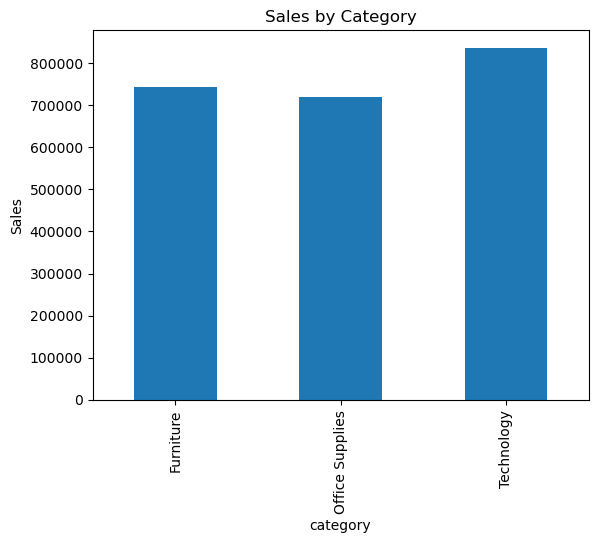

In [151]:
import matplotlib.pyplot as plt

# Doanh thu theo Category
df.groupby("category")["sales"].sum().plot(kind="bar")
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

Phân tích dataset theo timeseries

/var/folders/q9/jqxp3b7j5n16ldt5_zbylp0w0000gn/T/ipykernel_76767/2888510252.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key="order_date", freq="M"))["sales"]


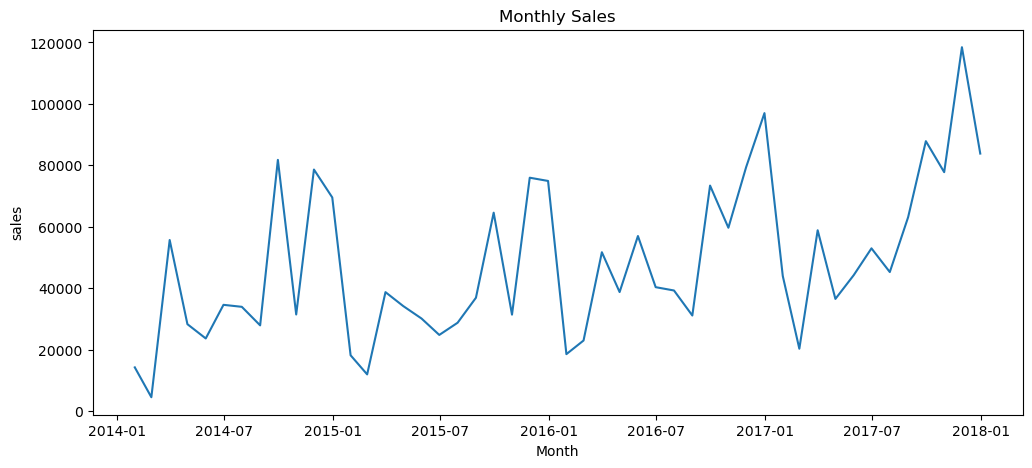

In [152]:
#convert cột order_date từ string sang dạng date time(vì ban đầu order_date là dạng string)
df["order_date"] = pd.to_datetime(df["order_date"])
#gom sales lại theo tháng
monthly_sales = (
    df.groupby(pd.Grouper(key="order_date", freq="M"))["sales"]
      .sum()
      .reset_index()
)
plt.figure(figsize=(12,5))
plt.plot(
    monthly_sales["order_date"],
    monthly_sales["sales"]
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("sales")
plt.show()

nhìn qua biểu đồ ta thấy dự sales thường tăng vào khoảng cuối năm => dự liệu có dạng seasonality


In [153]:
#nhìn sơ qua thì thấy được trend có xu hướng tăng theo năm, biến động mạnh và xu hướng sales tăng đột
#biến vào cuói năm. Có thể do các ngày lễ (blackfriday,giáng sinh?)


1. ĐÁNH GÍA THEO HIỆU XUẤT KINH DOANH 2016 THEO SALES VÀ PROFIT THÔNG QUA MARGIN

In [156]:
df_2016 = df[df['order_date'].dt.year == 2016].copy()
df_2017 = df[df['order_date'].dt.year == 2017].copy()

#tổng sales
sales_2016 = df_2016['sales'].sum()
sales_2017 = df_2017['sales'].sum()

#tổng profit
profit_2016 = df_2016['profit'].sum()
print(f"Sales 2016: {sales_2016}\nSales 2017: {sales_2017}")

Sales 2016: 609205.598
Sales 2017: 733215.2552


In [ ]:
#Margin = (profit/sales)*100(margin là lợi nhận thực tế sau khi
#trừ chi phí, thuế, lãi suất,...)
margin_2016 = (profit_2016/sales_2016)*100
margin_2016 = (profit_2016/sales_2016)*100


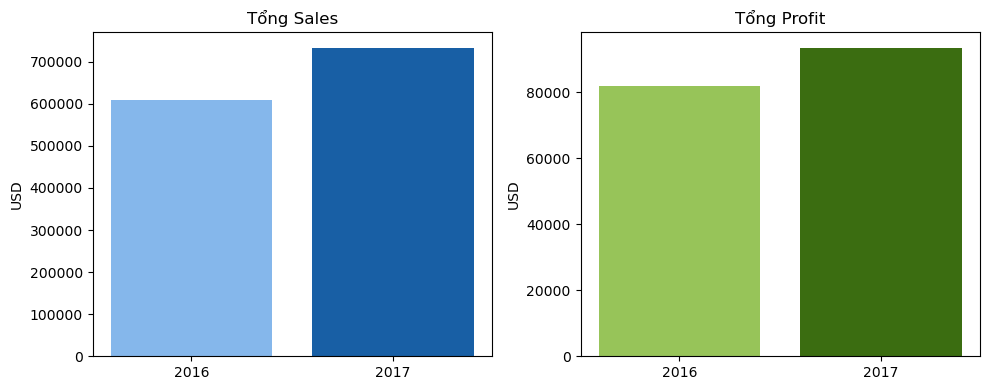

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# axes[0] là biểu đồ bên trái -> vẽ Sales
axes[0].bar(['2016', '2017'], [sales_2016, sales_2017], color=['#85B7EB', '#185FA5'])
axes[0].set_title('Tổng Sales')
axes[0].set_ylabel('USD')

# axes[1] là biểu đồ bên phải -> vẽ Profit
axes[1].bar(['2016', '2017'], [profit_2016, profit_2017], color=['#97C459', '#3B6D11'])
axes[1].set_title('Tổng Profit')
axes[1].set_ylabel('USD')

# tight_layout() tự canh khoảng cách giữa các subplot cho khỏi đè chữ lên nhau
plt.tight_layout()
plt.show()

2. ĐÁNH GIÁ PROFIT DỰA TRÊN TỈ LỆ DISCOUNT

In [161]:
# .assign() tạo cột mới an toàn hơn df['cột'] = ... khi làm việc với DataFrame đã lọc
# Nó trả về 1 DataFrame mới có thêm cột đó, không sửa trực tiếp vào df_2016 gốc

bins = [-0.01, 0, 0.2, 0.4, 1.0]
labels = ['0% (không giảm)', '1-20%', '21-40%', '41%+']

df_2016 = df_2016.assign(
    Discount_Band=pd.cut(df_2016['discount'], bins=bins, labels=labels)
)
df_2017 = df_2017.assign(
    Discount_Band=pd.cut(df_2017['discount'], bins=bins, labels=labels)
)

# Kiểm tra cột mới đã có chưa
print(df_2016['Discount_Band'].value_counts().sort_index())

Discount_Band
0% (không giảm)    1248
1-20%               976
21-40%              122
41%+                241
Name: count, dtype: int64
